<a href="https://colab.research.google.com/github/fzkmdly/Email_spam/blob/main/EmailSpam_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

c:\Users\Faiz Akhmad Daulay\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Download latest version
path = kagglehub.dataset_download("mohinurabdurahimova/maildataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Faiz Akhmad Daulay\.cache\kagglehub\datasets\mohinurabdurahimova\maildataset\versions\1437


In [3]:
df = pd.read_csv("/kaggle/input/maildataset/mail_data.csv")

df

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/maildataset/mail_data.csv'

In [ ]:
df.shape

(5572, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df.describe()

,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30


# Data Cleaning

In [ ]:
df.isnull().sum()

,0
Category,0
Message,0


In [ ]:
df.duplicated().sum()

np.int64(415)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Explanatory Data Analysist

In [ ]:
df['Category'].value_counts(normalize=True) * 100

,proportion
Category,
ham,87.570293
spam,12.429707


In [ ]:
df['Category'].value_counts()

,count
Category,
ham,4516
spam,641


In [ ]:
df['Email_length'] = df['Message'].apply(len)

df

/tmp/ipykernel_1462/624715197.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Email_length'] = df['Message'].apply(len)


,Category,Message,Email_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,160
5568,ham,Will ü b going to esplanade fr home?,36
5569,ham,"Pity, * was in mood for that. So...any other s...",57
5570,ham,The guy did some bitching but I acted like i'd...,125


In [ ]:
df['Email_length'].describe()

,Email_length
count,5157.000000
mean,79.103936
std,58.382922
min,2.000000
25%,36.000000
50%,61.000000
75%,118.000000
max,910.000000


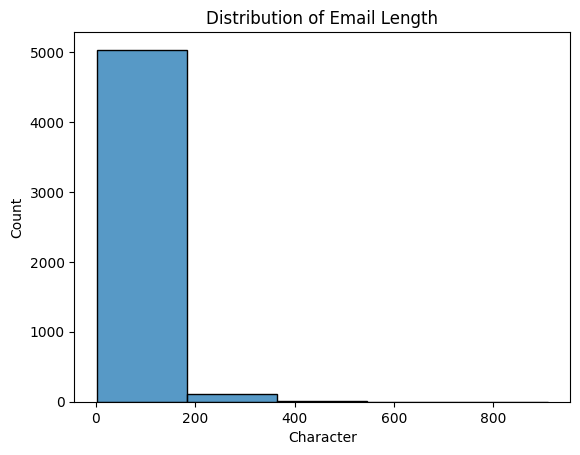

In [ ]:
sns.histplot(df['Email_length'], bins=5)
plt.xlabel('Character')
plt.title('Distribution of Email Length')
plt.show()

Text(0.5, 1.0, 'Distribution of Email Length per Category')

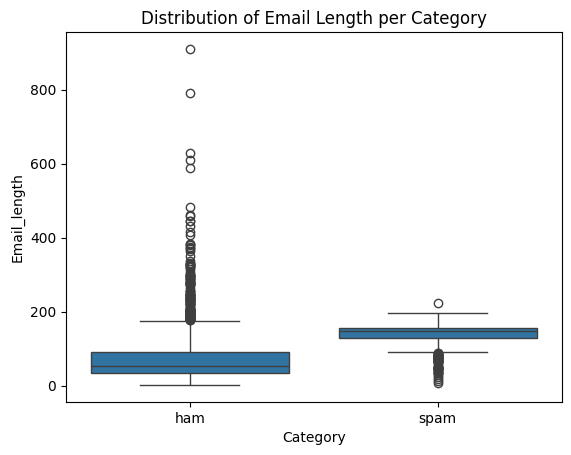

In [ ]:
sns.boxplot(df, x="Category", y="Email_length")
plt.title("Distribution of Email Length per Category")

In [ ]:
df.groupby('Category')['Email_length'].mean()

,Email_length
Category,
ham,70.869353
spam,137.118565


In [ ]:
df['Word_counts'] = df['Message'].apply(lambda x: len(x.split()))

/tmp/ipykernel_1462/1453644891.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Word_counts'] = df['Message'].apply(lambda x: len(x.split()))


In [ ]:
df.groupby('Category')['Word_counts'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
ham,4516.0,14.24,11.18,1.0,7.0,11.0,19.0,171.0
spam,641.0,23.66,6.04,1.0,21.0,25.0,28.0,35.0


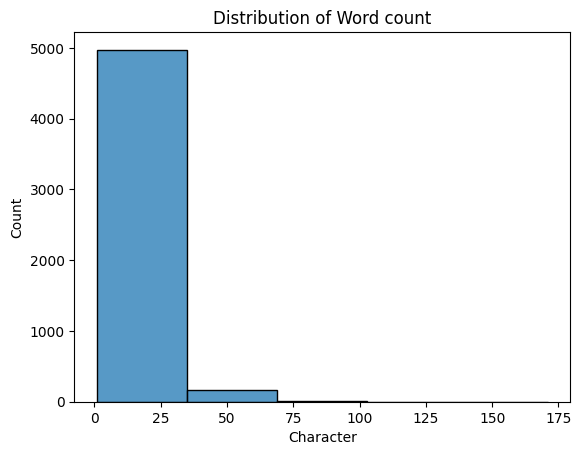

In [ ]:
sns.histplot(df['Word_counts'], bins=5)
plt.xlabel('Character')
plt.title('Distribution of Word count')
plt.show()

Text(0.5, 1.0, 'Distribution of Word count per Category')

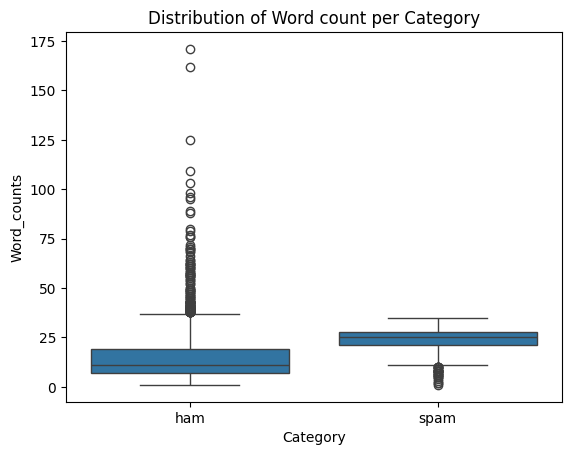

In [ ]:
sns.boxplot(df, x="Category", y="Word_counts")
plt.title("Distribution of Word count per Category")

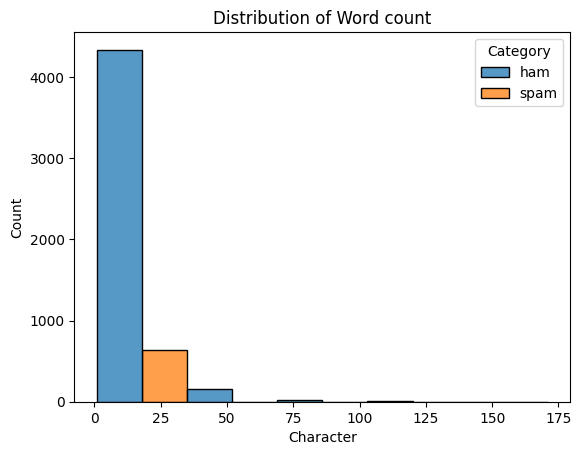

In [ ]:
sns.histplot(df, x='Word_counts', hue='Category', bins=5, multiple='dodge')
plt.xlabel('Character')
plt.title('Distribution of Word count')
plt.show()

# Data Splitting

In [ ]:
df

,Category,Message,Email_length,Word_counts
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,160,30
5568,ham,Will ü b going to esplanade fr home?,36,8
5569,ham,"Pity, * was in mood for that. So...any other s...",57,10
5570,ham,The guy did some bitching but I acted like i'd...,125,26


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import RobustScaler
from scipy.sparse import hstack

In [ ]:
x = df.iloc[:, 1:]
y = df['Category']

In [ ]:
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

X_train_text = tfidf.fit_transform(X_train['Message'])
X_test_text = tfidf.transform(X_test['Message'])

In [ ]:
Scaler = RobustScaler()
X_train_num = Scaler.fit_transform(X_train[['Email_length', 'Word_counts']])
X_test_num = Scaler.transform(X_test[['Email_length', 'Word_counts']])

In [ ]:
X_train_finalized = hstack([X_train_text, X_train_num])
X_test_finalized = hstack([X_test_text, X_test_num])

In [ ]:
y_train_coded = y_train.copy()

y_train_coded = y_train_coded.map({
    'ham': 0,
    'spam': 1
})

y_train_coded

,Category
4796,0
764,0
3657,0
5098,1
4834,1
...,...
2954,1
266,0
4115,0
2760,0


In [ ]:
y_test_coded = y_test.copy()

y_test_coded = y_test_coded.map({
    'ham': 0,
    'spam': 1
})

y_test_coded

,Category
3849,0
1434,0
3996,0
4124,0
2406,0
...,...
4144,1
543,0
4295,1
1514,0


# Modelling

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report